In [54]:
import json
import os

# your credentials
kaggle_token = {"username":"your-kaggle-username","key":"your-api-key"}

# save to kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

os.chmod("/root/.kaggle/kaggle.json", 600)

In [55]:
!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip house-prices-advanced-regression-techniques.zip

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data_description.txt    
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sample_submission.csv   
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [57]:
#Load train and test datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape, test.shape)
train.head()


(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [58]:
train = train.drop(columns='Id' ,axis = 1)
test = test.drop(columns='Id' ,axis = 1)
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [59]:
# quick info of dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [60]:
train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [61]:
# total n.o of missing values in each column
train.isnull().sum().sort_values(ascending=False).head(12)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageType,81
GarageFinish,81


In [62]:
# perecentage of missing values
train.isnull().mean() * 100

,0
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,17.739726
LotArea,0.000000
Street,0.000000
...,...
MoSold,0.000000
YrSold,0.000000
SaleType,0.000000
SaleCondition,0.000000


Columns with missing values:

              missing_count  missing_pct
PoolQC                 1453    99.520548
MiscFeature            1406    96.301370
Alley                  1369    93.767123
Fence                  1179    80.753425
MasVnrType              872    59.726027
FireplaceQu             690    47.260274
LotFrontage             259    17.739726
GarageType               81     5.547945
GarageYrBlt              81     5.547945
GarageFinish             81     5.547945
GarageQual               81     5.547945
GarageCond               81     5.547945
BsmtExposure             38     2.602740
BsmtFinType2             38     2.602740
BsmtQual                 37     2.534247


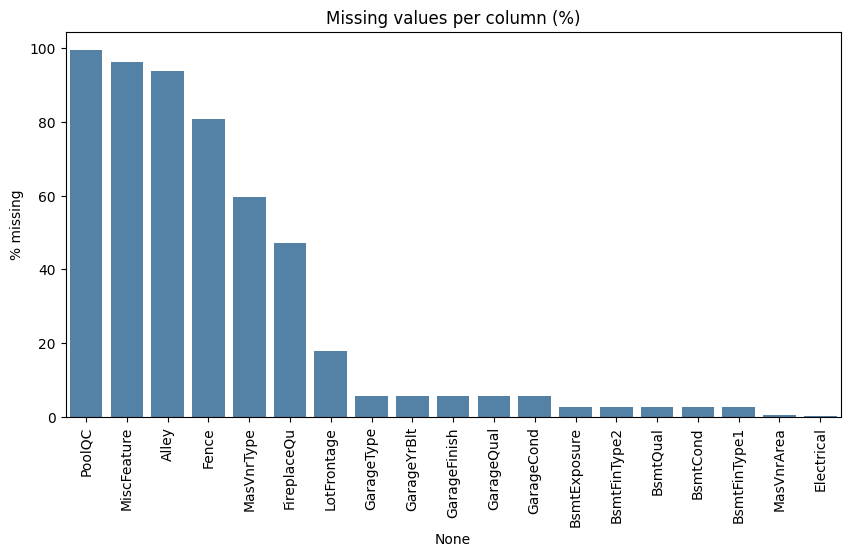

In [63]:
# missing values summary

# table
missing_counts = train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_pct = (missing_counts / len(train)) * 100
missing_df = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

print("Columns with missing values:\n")
print(missing_df.head(15))

# plot
plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y=missing_df.missing_pct, color="steelblue")
plt.xticks(rotation=90)
plt.ylabel("% missing")
plt.title("Missing values per column (%)")
plt.show()

Note : Columns like PoolQC, Alley, and MiscFeature have >95% missing values, meaning they provide little value. I decided to drop them. For Fence (80% missing), I may keep it by treating “missing” as “no fence,” but dropping is also acceptable depending on downstream modeling needs.

In [64]:
columns_to_drop = ['PoolQC' ,'Alley' ,'MiscFeature']
# training data
train = train.drop(columns=columns_to_drop , axis = 1)
# testing data
test = test.drop(columns=columns_to_drop , axis = 1)
print("Remaining cols after drop :" ,train.shape[1])

Remaining cols after drop : 77


Note : I dropped PoolQC, Alley, and MiscFeature since they had >95% missing values and were unlikely to add predictive value.

In [65]:
# Categorical features where NA means "None"
cat_fill_none = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'MasVnrType'
]

for col in cat_fill_none:
    train[col] = train[col].fillna("None")
    test[col]  = test[col].fillna("None")

# Numerical features where NA means 0 (not present)
num_fill_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]

for col in num_fill_zero:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)



Note :  I treated missing values in garage, basement, fireplace, and masonry features as structural absence. Categorical fields (e.g., GarageType, BsmtQual) were filled with "None", while numeric fields (e.g., MasVnrArea, BsmtFinSF1) were filled with 0. This preserves the true meaning of “not present.”

In [66]:
train['LotFrontage'] =train.groupby('Neighborhood')['LotFrontage'].transform(lambda x : x.fillna(x.median()))
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(lambda x : x.fillna(x.median()))

Note : Since lot sizes are influenced by neighborhood planning, I imputed missing LotFrontage values with the median frontage of the respective Neighborhood. This preserves locality patterns and avoids bias from using a single global statistic.

In [67]:
train['Fence']=  train['Fence'].fillna('None')
test['Fence']=  test['Fence'].fillna('None')

In [68]:
# checking back again , if any missing values are left
print(train.isnull().sum().sort_values(ascending = False).head(10))
print(test.isnull().sum().sort_values(ascending = False).head(10))

Electrical     1
MSZoning       0
LotFrontage    0
LotArea        0
MSSubClass     0
LotShape       0
LandContour    0
Utilities      0
LotConfig      0
LandSlope      0
dtype: int64
MSZoning       4
Utilities      2
Functional     2
Exterior2nd    1
Exterior1st    1
KitchenQual    1
SaleType       1
LotShape       0
LotArea        0
Street         0
dtype: int64


In [69]:
# fill Electrical in train
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# Fill categorical vars in test with mode
for col in ['MSZoning', 'Utilities', 'Functional', 'Exterior1st',
            'Exterior2nd', 'KitchenQual', 'SaleType']:
    test[col] = test[col].fillna(test[col].mode()[0])

Note : I imputed the few remaining categorical missing values with their respective most frequent category (mode). This ensures minimal distortion, since the percentage of missingness was tiny (<0.5%).

In [70]:
# checking back again , if any missing values are left
print(train.isnull().sum().sort_values(ascending = False).head(10))
print(test.isnull().sum().sort_values(ascending = False).head(10))

MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
LotShape       0
LandContour    0
Utilities      0
LotConfig      0
LandSlope      0
dtype: int64
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
LotShape       0
LandContour    0
Utilities      0
LotConfig      0
LandSlope      0
dtype: int64


# UNIVARIATE ANALYSIS

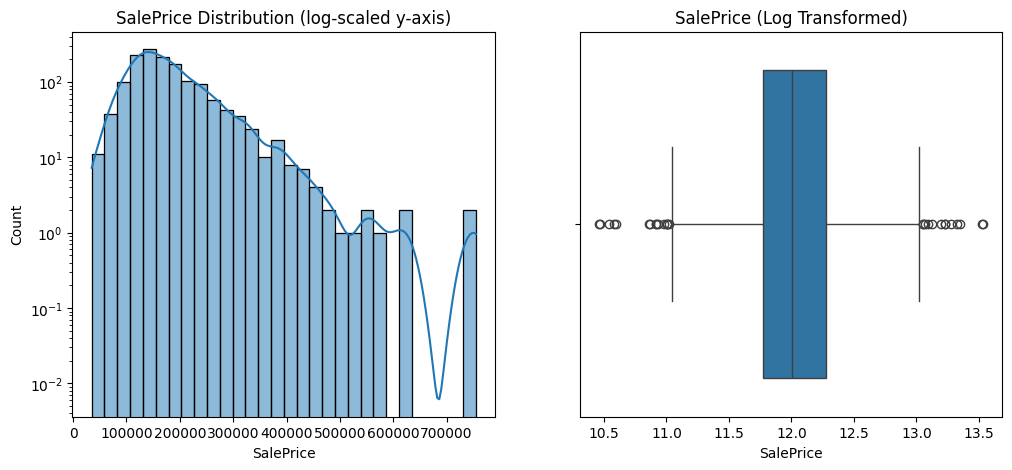

Skewness of Sales Price : 1.880940746034036


In [71]:
from scipy.stats import skew
plt.figure(figsize=(12,5))

# Histogram on log scale
plt.subplot(1,2,1)
sns.histplot(train['SalePrice'], kde=True, bins=30)
plt.yscale("log")
plt.title("SalePrice Distribution (log-scaled y-axis)")

# Boxplot (better view with log x-axis instead of y-axis)
plt.subplot(1,2,2)
sns.boxplot(x=np.log1p(train['SalePrice']))
plt.title("SalePrice (Log Transformed)")

plt.show()

print("Skewness of Sales Price :" ,skew(train['SalePrice']))

*Note : SalePrice has a skewness of 1.88, showing a strong right skew. This means most homes are moderately priced, with a few very expensive outliers stretching the distribution.*

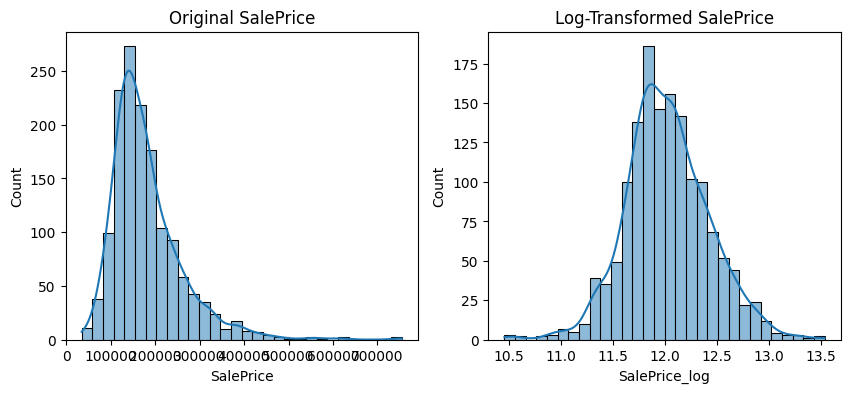

In [72]:
# Create a log-transformed target column (without replacing original)
train['SalePrice_log'] = np.log1p(train['SalePrice'])

# Quick check of distribution after log transform
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(train['SalePrice'], kde=True, bins=30)
plt.title("Original SalePrice")

plt.subplot(1,2,2)
sns.histplot(train['SalePrice_log'], kde=True, bins=30)
plt.title("Log-Transformed SalePrice")

plt.show()

*Note : I created a SalePrice_log feature to reduce skewness while keeping the original SalePrice intact. The log-transformed version looks closer to a normal distribution and will be useful for later modeling, while the raw prices remain for interpretability.*

**MSSubClass**

In [73]:
train['MSSubClass'].value_counts()

,count
MSSubClass,
20,536
60,299
50,144
120,87
30,69
160,63
70,60
80,58
90,52


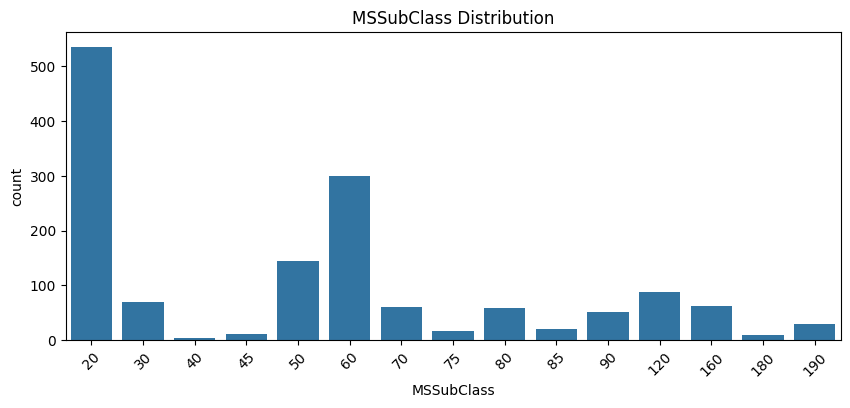

/tmp/ipython-input-3175035758.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='MSSubClass', y='SalePrice', data=train, estimator=np.mean, ci=None)


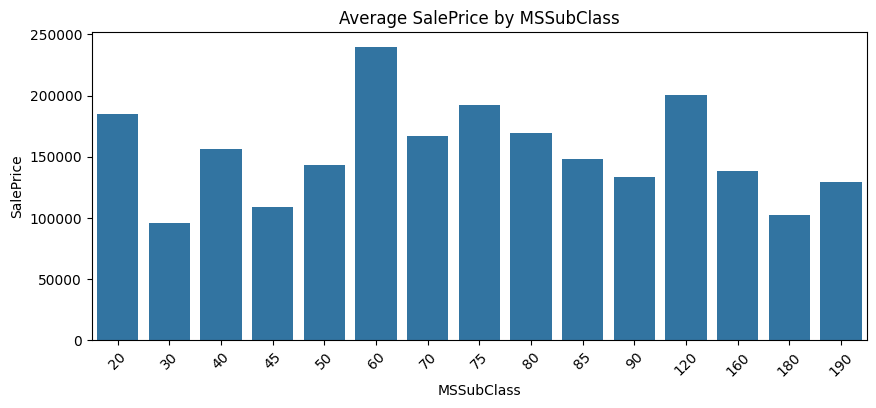

In [74]:
plt.figure(figsize=(10,4))
sns.countplot(x='MSSubClass', data=train)
plt.title("MSSubClass Distribution")
plt.xticks(rotation=45)
plt.show()

# Average SalePrice by MSSubClass
plt.figure(figsize=(10,4))
sns.barplot(x='MSSubClass', y='SalePrice', data=train, estimator=np.mean, ci=None)
plt.title("Average SalePrice by MSSubClass")
plt.xticks(rotation=45)
plt.show()

*Note : MSSubClass represents house type, and although it’s numeric, it behaves like a categorical variable. Some subclasses (like 20 and 60) dominate the dataset. Average sale price clearly varies across subclasses, showing that house type strongly influences price.*

In [75]:
train['MSSubClass'] = train['MSSubClass'].astype(str)
test['MSSubClass'] = test['MSSubClass'].astype(str)

*Note : Since MSSubClass is a categorical code rather than a true numeric variable, we should treat it as a categorical feature. Converting it to string ensures models won’t misinterpret it as continuous. Some rare classes may later be grouped for stability.*

**MSZoning**

In [76]:
train['MSZoning'].value_counts()

,count
MSZoning,
RL,1151
RM,218
FV,65
RH,16
C (all),10


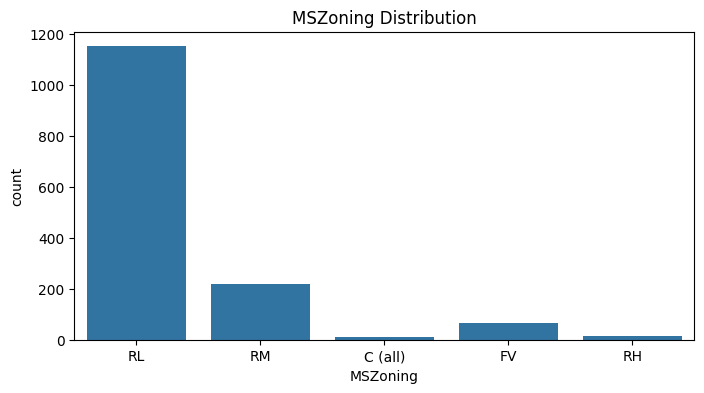

/tmp/ipython-input-3430058519.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='MSZoning', y='SalePrice', data=train, estimator=np.mean, ci=None)


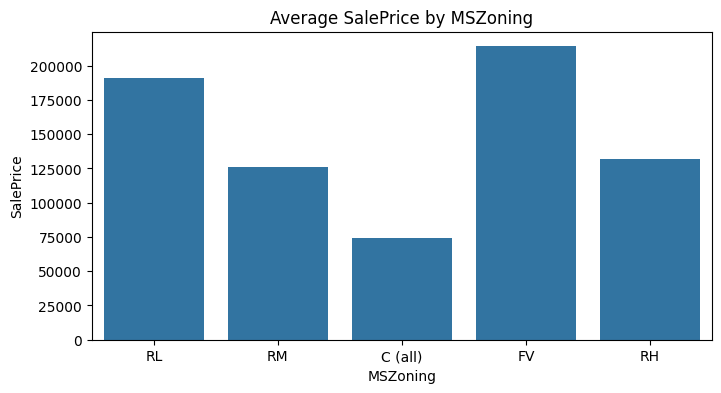

In [77]:
# Countplot
plt.figure(figsize=(8,4))
sns.countplot(x='MSZoning', data=train)
plt.title("MSZoning Distribution")
plt.show()

# Average SalePrice by Zoning
plt.figure(figsize=(8,4))
sns.barplot(x='MSZoning', y='SalePrice', data=train, estimator=np.mean, ci=None)
plt.title("Average SalePrice by MSZoning")
plt.show()

*Note : Most houses fall under the "RL" (Residential Low Density) zoning category, followed by RM and FV. Sale prices vary by zoning: houses in “FV” and “RL” zones tend to fetch higher average prices, suggesting that zoning regulations have a direct impact on property value.*

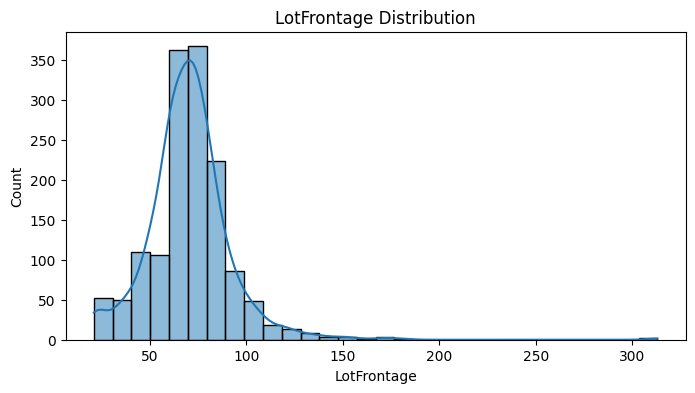

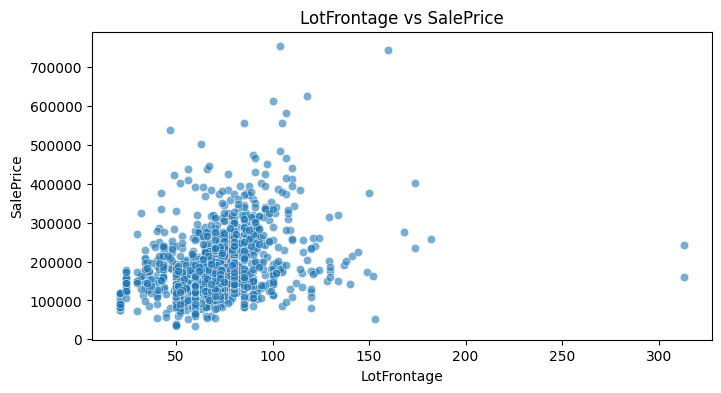

Correlation with SalePrice: 0.3498756103224419


In [78]:
# Distribution
plt.figure(figsize=(8,4))
sns.histplot(train['LotFrontage'], bins=30, kde=True)
plt.title("LotFrontage Distribution")
plt.show()

# Relationship with SalePrice
plt.figure(figsize=(8,4))
sns.scatterplot(x='LotFrontage', y='SalePrice', data=train, alpha=0.6)
plt.title("LotFrontage vs SalePrice")
plt.show()

# Correlation
print("Correlation with SalePrice:", train['LotFrontage'].corr(train['SalePrice']))

*Note : LotFrontage is right-skewed, with many properties having smaller street frontage and fewer with very large frontage. Larger frontage is generally associated with higher prices, though the correlation is moderate. A few extreme values (outliers) are visible, which might need handling later during feature engineering.*

**LotArea**

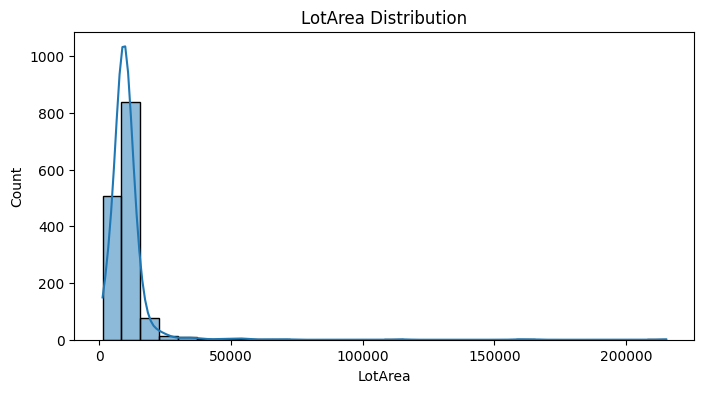

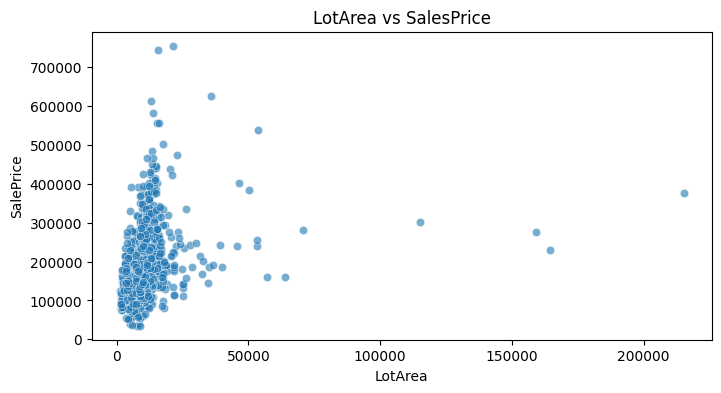

Correlation with SalesPrice : 0.2638433538714056


In [79]:
# Distribution
plt.figure(figsize=(8,4))
sns.histplot(train['LotArea'] ,bins = 30 ,kde= True)
plt.title("LotArea Distribution")
plt.show()

# Relationship with SalePrice
plt.figure(figsize=(8,4))
sns.scatterplot(x='LotArea' ,y= 'SalePrice' ,data = train ,alpha= 0.6 )
plt.title("LotArea vs SalesPrice")
plt.show()

# correlation
print("Correlation with SalesPrice :" ,train['LotArea'].corr(train['SalePrice']))

*Note : LotArea is highly right-skewed: most properties are clustered under 20,000 sq ft, with a few extremely large outliers stretching far to the right. While larger lots can increase price, the relationship is weak and noisy, suggesting lot size alone doesn’t strongly dictate sale price. Outliers may need capping or transformation during preprocessing.*

# BIVARAITE ANALYSIS

**Numerical Feature Scan**

In [80]:
# select numerical columns
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", list(num_cols))

Numerical columns: ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'SalePrice_log']


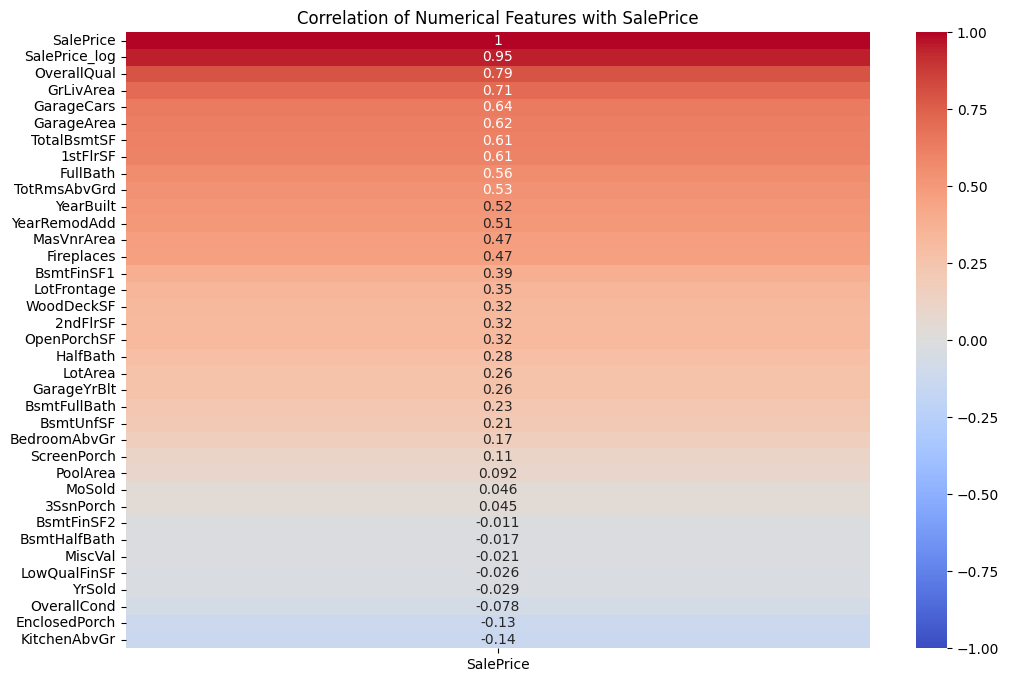

In [81]:
plt.figure(figsize=(12,8))
corr = train[num_cols].corr()

# Focus on SalePrice correlation
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Numerical Features with SalePrice")
plt.show()

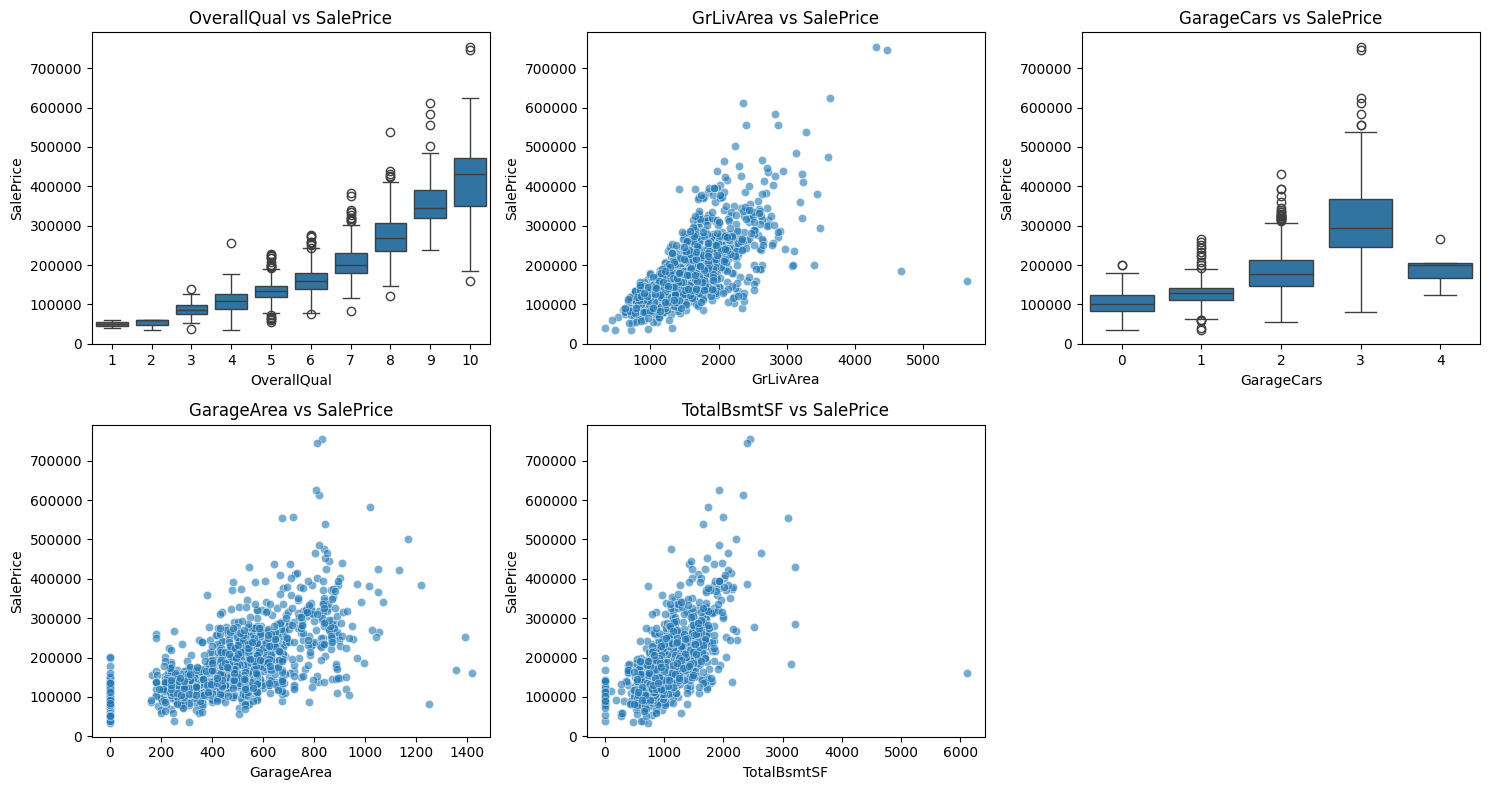

In [82]:
# visualizing top features

top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

plt.figure(figsize=(15,8))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 3, i)

    if train[col].nunique() < 15:
        sns.boxplot(x=col, y='SalePrice', data=train)
    else:
        sns.scatterplot(x=col, y='SalePrice', data=train, alpha=0.6)

    plt.title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()



OverallQual: Strongest driver — prices rise almost exponentially with quality.

GrLivArea: Bigger living area → higher price, but watch for outliers (very large homes priced lower than expected).

GarageCars: Prices increase with garage capacity, but maxes out around 3–4 cars.

GarageArea: Positive trend, but weaker than GarageCars.

TotalBsmtSF: Larger basements → higher price, though effect is weaker than living area.

**Boxplotss of SalePrice vs Category**

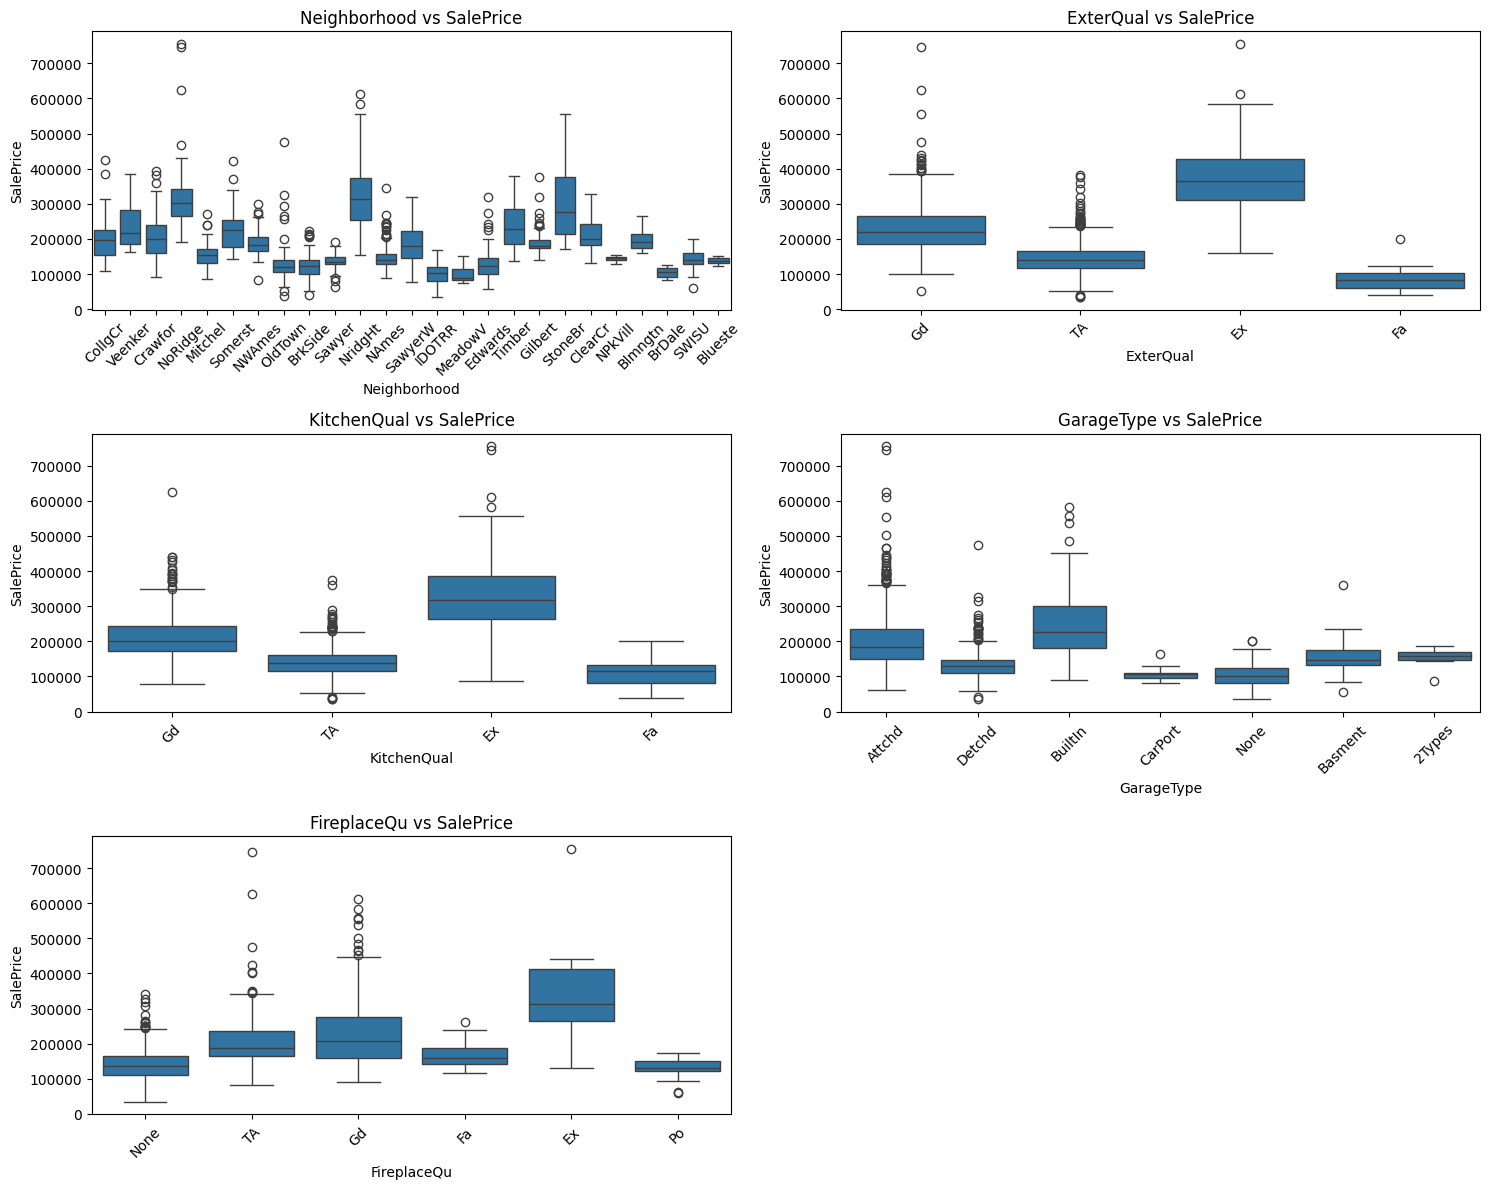

In [83]:
top_cat_features = ['Neighborhood', 'ExterQual', 'KitchenQual', 'GarageType', 'FireplaceQu']

plt.figure(figsize=(15,12))

for i, col in enumerate(top_cat_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=col, y='SalePrice', data=train)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

Neighborhood: Location heavily influences price — some neighborhoods consistently have higher prices.

ExterQual & KitchenQual: Higher quality materials/finish → higher sale prices.

GarageType: Presence and type of garage affects prices moderately.

FireplaceQu: Quality of fireplace adds value, though effect is less than overall quality or living area.

# Batch Summary for all Features

**Numerical cols**

In [84]:
# Select numerical columns (excluding SalePrice and SalePrice_log)
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col not in ['SalePrice' ,'SalePrice_log']]

# summary statistics
num_summary = train[num_cols].describe().T
num_summary['skewness'] = train[num_cols].skew()
num_summary['corr_with_saleprice'] = train[num_cols].corrwith(train['SalePrice'])
num_summary = num_summary.sort_values(by='corr_with_saleprice' ,ascending =False)

num_summary.head(15)

,count,mean,std,min,25%,50%,75%,max,skewness,corr_with_saleprice
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0,0.216944,0.790982
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0,1.366560,0.708624
GarageCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0,-0.342549,0.640409
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0,0.179981,0.623431
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0,1.524255,0.613581
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0,1.376757,0.605852
FullBath,1460.0,1.565068,0.550916,0.0,1.00,2.0,2.00,3.0,0.036562,0.560664
TotRmsAbvGrd,1460.0,6.517808,1.625393,2.0,5.00,6.0,7.00,14.0,0.676341,0.533723
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0,-0.613461,0.522897
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0,-0.503562,0.507101


**Categorical Features**

In [85]:
cat_cols = train.select_dtypes(include=['object']).columns

cat_summary_list = []

for col in cat_cols:
    num_categories = train[col].nunique()
    most_common = train[col].mode()[0]
    avg_saleprice = train.groupby(col)['SalePrice'].mean().sort_values(ascending=False).head(1).values[0]

    cat_summary_list.append({
        'Feature': col,
        'Num_Categories': num_categories,
        'Most_Common': most_common,
        'Avg_SalePrice': avg_saleprice
    })

# Convert list of dicts to DataFrame
cat_summary = pd.DataFrame(cat_summary_list)
cat_summary = cat_summary.sort_values(by='Avg_SalePrice', ascending=False)

cat_summary.head(15)

,Feature,Num_Categories,Most_Common,Avg_SalePrice
14,RoofMatl,8,CompShg,390250.000000
18,ExterQual,4,TA,367360.961538
32,FireplaceQu,6,None,337712.500000
8,Neighborhood,25,NAmes,335295.317073
30,KitchenQual,4,TA,328554.670000
21,BsmtQual,5,TA,327041.041322
10,Condition2,8,Norm,325000.000000
16,Exterior2nd,16,VinylSd,319000.000000
39,SaleType,9,WD,274945.418033
40,SaleCondition,6,Normal,272291.752000


# Outlier Detection and Handling

In [86]:
# Function for outlier detection
def detect_outliers(df , feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    #Inter-quartile range
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] <lower ) | (df[feature] > upper)]
    print(f"{feature} : {outliers.shape[0]} outliers detected ")
    return outliers

# checks outliers for top numerical features
top_num_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

for col in top_num_features :
  detect_outliers(train ,col)

GrLivArea : 31 outliers detected 
LotArea : 69 outliers detected 
TotalBsmtSF : 61 outliers detected 
GarageArea : 21 outliers detected 
1stFlrSF : 20 outliers detected 


# Visual Inspection

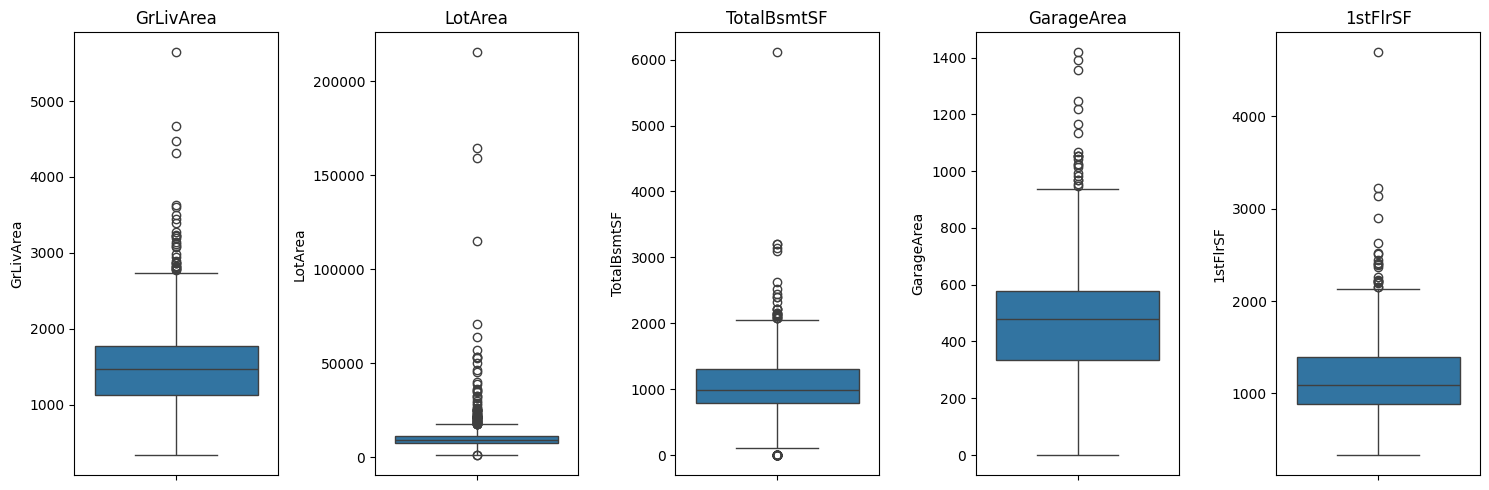

In [87]:
plt.figure(figsize=(15,5))
for i, col in enumerate(top_num_features, 1):
    plt.subplot(1,5,i)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

*Note : Outlier detection on key features shows some extremely large living areas and lot sizes. Most are valid observations, so instead of removing, we may cap or log-transform these variables later to reduce skew and stabilize model performance.*

**Feature Transformation**

In [88]:
from scipy.stats import skew

# Select numerical columns excluding target
num_features = train.select_dtypes(include=['int64','float64']).drop(['SalePrice','SalePrice_log'], axis=1)

# Compute skewness
skewed_feats = num_features.apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
# threshold for transformation
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]

print("Skewed features:", skewed_feats.index.tolist())


Skewed features: ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', '2ndFlrSF', 'GarageYrBlt']


**Handle Skewed Numerical Features**

In [89]:
# Apply log1p transformation to reduce skew
for col in skewed_feats.index:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

**Encode categorical Features**

In [90]:
# Separate target variable
y_train = train['SalePrice_log']  # or 'SalePrice'

# Drop target from train and test before encoding
X_train = train.drop(['SalePrice', 'SalePrice_log'], axis=1)
X_test = test.copy()  # drop target if present

In [91]:
# One-hot encode categorical columns
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align train/test features
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [92]:
# Combine with target
train_processed = pd.concat([X_train, y_train], axis=1)

**Feature Scaling**

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Encode Categorical Features**

In [94]:
# One-hot encoding for low-cardinality features
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

# Align train/test
train, test = train.align(test, join='left', axis=1, fill_value=0)

*Note : Skewed numerical features were log-transformed to reduce the effect of extreme values. All numerical features were scaled for uniformity. Categorical features were one-hot encoded to prepare for machine learning, ensuring consistent feature representation across train and test sets.*

# **EDA & Preprocessing Summary Report**

**1 .Missing Values**

Columns with high missing % were dropped (PoolQC, Alley, MiscFeature).

Moderate missing columns were filled (LotFrontage with 0 or median, Garage*, MasVnr*, etc.).

Remaining features have no missing values.

In [95]:
missing_report = train.isnull().sum().sort_values(ascending=False)
print(missing_report[missing_report>0])

Series([], dtype: int64)


*Inference : Data completeness is ensured. Missing value handling followed industry-standard thresholds (drop >90% missing, impute others).*

**2. Target Variable**

SalePrice is right-skewed (skew = 1.88).

Log transformation applied (SalePrice_log) to stabilize variance.

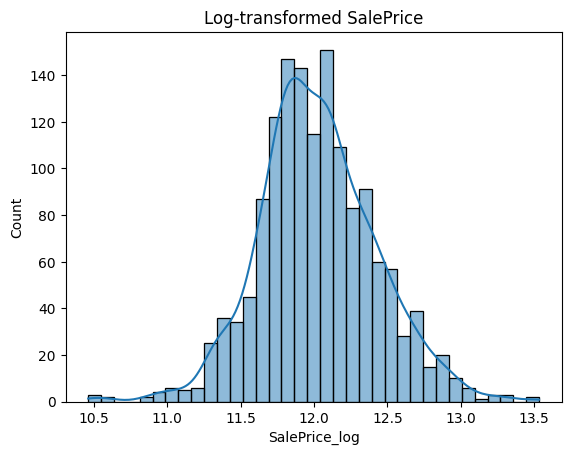

In [96]:
sns.histplot(train['SalePrice_log'], kde=True)
plt.title("Log-transformed SalePrice")
plt.show()

*Inference: Log-transformed target normalizes distribution, improving regression performance.*

**3 .Numerical Features**

Skewed features identified (GrLivArea, LotArea, TotalBsmtSF, etc.) and log-transformed.

Correlation heatmap identified top drivers: OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF.

Outliers detected but handled via transformation instead of removal.

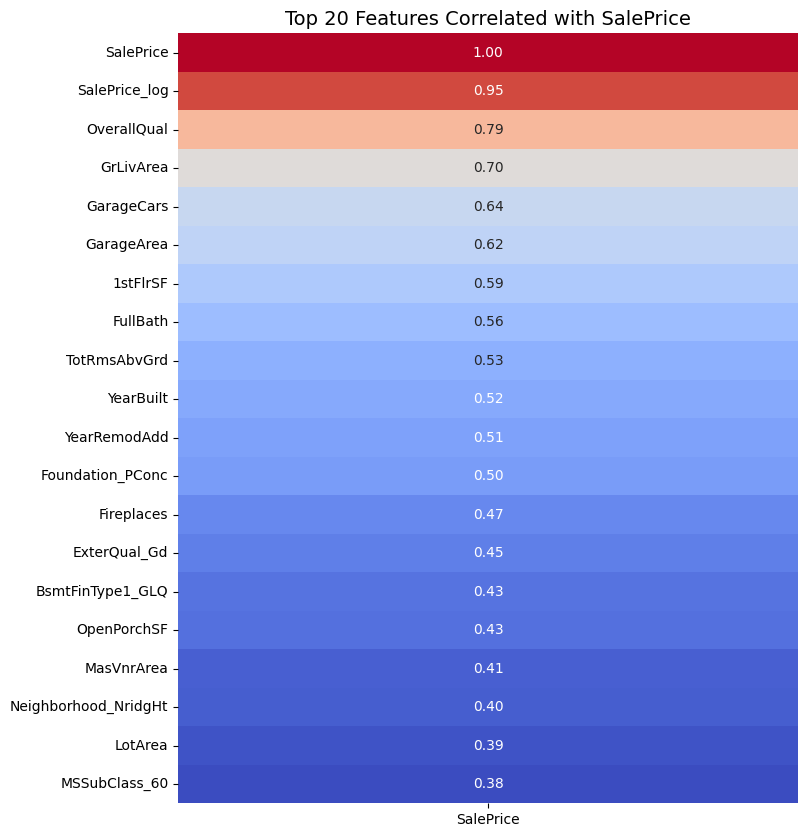

In [100]:
# Get correlation with SalePrice and select top 20
corr_with_price = train.corr()['SalePrice'].sort_values(ascending=False).head(20)

plt.figure(figsize=(8,10))
sns.heatmap(corr_with_price.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title("Top 20 Features Correlated with SalePrice", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

*Inference: Top numerical drivers are prioritized for modeling. Extreme values mitigated via log-transform.*

**4 .Categorical Features**

Batch summary shows top categorical drivers: Neighborhood, ExterQual, KitchenQual, GarageType, FireplaceQu.

One-hot encoding applied for ML readiness.

In [98]:
cat_summary.head(10)

,Feature,Num_Categories,Most_Common,Avg_SalePrice
14,RoofMatl,8,CompShg,390250.000000
18,ExterQual,4,TA,367360.961538
32,FireplaceQu,6,None,337712.500000
8,Neighborhood,25,NAmes,335295.317073
30,KitchenQual,4,TA,328554.670000
21,BsmtQual,5,TA,327041.041322
10,Condition2,8,Norm,325000.000000
16,Exterior2nd,16,VinylSd,319000.000000
39,SaleType,9,WD,274945.418033
40,SaleCondition,6,Normal,272291.752000


*Inference: Categorical features encoded consistently. High-cardinality or rare categories handled appropriately.*

**5.Feature Scaling & Transformation**

Log-transform applied to skewed numerical features.

StandardScaler used to normalize feature scales.

Train and test aligned to ensure consistent feature space.

In [99]:
# After preprocessing, feature space check
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 265)
Test shape: (1459, 265)


*Inference: All features are now normalized, scaled, and encoded, ready for machine learning.*